In [5]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install transformers pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git

In [9]:
!pip install -q datasets

In [12]:
import json
from datasets import load_dataset

captions = [{"file_name": "a2.jpg", "text": "landslide on a hill"},
{"file_name": "a3.jpg", "text": "landslide and rockslide on a road on a hill"},
{"file_name": "a4.jpg", "text": "landslide on a large hill"},
{"file_name": "a5.jpg", "text": "landslide on a road"},
{"file_name": "a6.jpg", "text": "property damage because of landlisde on a hill"},
{"file_name": "a7.jpg", "text": "man cleaning the snow because of snowstorm"},
{"file_name": "a8.jpg", "text": "landslide on a raod on a hill"},
{"file_name": "a9.jpg", "text": "landslide on a road on a hill"},
{"file_name": "a10.jpg", "text": "property damage due to heavy snowstorm"},
{"file_name": "a11.jpg", "text": "fallen trees dues to hurricane and typhoon"},
{"file_name": "a12.jpg", "text": "strong spiraling winds causing typhoon and hurricane"},
{"file_name": "a13.jpg", "text": "a building caught on fire and causing lot of smoke"},
{"file_name": "a14.jpg", "text": "man looking at jungle caught on fire causing wildfires"},
{"file_name": "a15.jpg", "text": "remains of houses and properties after a fire"},
{"file_name": "a16.jpg", "text": "wildfire at a jungle at night"},
{"file_name": "a17.jpg", "text": "damaged property after a typhoon and hurricane"},
{"file_name": "a18.jpg", "text": "heavy flooding on road with cars and people"},
{"file_name": "a19.jpg", "text": "house balcony with chairs and tables covered in snow because of snowstorm"},
{"file_name": "a20.jpg", "text": "heavy flooding on roads near houses"},
{"file_name": "a21.jpg", "text": "cracked road because of strong earthquake"},
{"file_name": "a22.jpg", "text": "heavy snowstrom causing trees and house to be covered in snow"},
{"file_name": "a23.jpg", "text": "roads covered in heavy snow around people"},
{"file_name": "a24.jpg", "text": "burnt remains of trees and house after a fire"},
{"file_name": "a25.jpg", "text": "burnt remains of cars after a fire"},
{"file_name": "a26.jpg", "text": "heavy snowstorm covers house with snow"},
{"file_name": "a27.jpg", "text": "heavy flooding with people and houses half submerged in water"},
{"file_name": "a28.jpg", "text": "heavy snowfall and blizzard tree covered in snow"},
{"file_name": "a29.jpg", "text": "heavy flooding water below knee level of people"},
{"file_name": "a30.jpg", "text": "fire inside building because smoke coming out of it"},
{"file_name": "a31.jpg", "text": "houses destroyed due to landslide"},
{"file_name": "a32.jpg", "text": "heavy snowstorm and blizzard trees houses cars raods billboards covered in snow"},
{"file_name": "a33.jpg", "text": "heavy flooding one third of buildings submerged in water"},
{"file_name": "a34.jpg", "text": "strong earthquake road cracked open"},
{"file_name": "a35.jpg", "text": "stron earthquake damaged building"},
{"file_name": "a36.jpg", "text": "snowstorm and blizzard car vehicle trees building covered in snow"},
{"file_name": "a37.jpg", "text": "building on fire firefighter trying to calm the fire at night"},
{"file_name": "a38.jpg", "text": "heavy snowfall houses roads covered in snow"},
{"file_name": "a39.jpg", "text": "strong earthquake damamged building"},
{"file_name": "a40.jpg", "text": "not a disaster"},
{"file_name": "a41.jpg", "text": "not a disaster"},
{"file_name": "a42.jpg", "text": "not a disaster"},
{"file_name": "a43.jpg", "text": "not a disaster"},
{"file_name": "a44.jpg", "text": "not a disaster"},
{"file_name": "a45.jpg", "text": "heavy flooding with one third of houses submerged in water"},
{"file_name": "a46.jpg", "text": "fire and heavy smoke from small houses"},
{"file_name": "a47.jpg", "text": "flooding around the houses"},
{"file_name": "a48.jpg", "text": "not a disaster"},
{"file_name": "a49.jpg", "text": "not a disaster"},
{"file_name": "a50.jpg", "text": "strong winds hurricane and typhoon"},
{"file_name": "a51.jpg", "text": "strong winds hurricane and typhoon"},
{"file_name": "a52.jpg", "text": "damaged property due to hurricane typhoon"},
{"file_name": "a53.jpg", "text": "damaged property due to hurricane typhoon"},
{"file_name": "a54.jpg", "text": "fallen trees due to hurricane typhoon"},
{"file_name": "a55.jpg", "text": "damaged preperty and broken trees due to hurricane typhoon"},]

#root = "/home/xim/xu2202_main/caption_db"  # Folder containing images
#metadata_path = "/home/xim/xu2202_main/caption_db/metadata.jsonl"  # Path to save metadata.jsonl file

root = "/home/xim/xu2202_main/caption_db/"

# add metadata.jsonl file to this folder
with open(root + "metadata.jsonl", 'w') as f:
    for item in captions:
        f.write(json.dumps(item) + "\n")


In [14]:
from datasets import load_dataset 

dataset = load_dataset("imagefolder", data_dir=root, split="train")

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [15]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 54
})

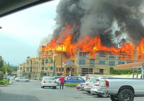

In [19]:
example = dataset[3]
image = example["image"]
width, height = image.size
display(image.resize((int(0.3*width), int(0.3*height))))
     

In [20]:
example["text"]

'a building caught on fire and causing lot of smoke'

In [8]:
from torch.utils.data import Dataset

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")

        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}

        return encoding

In [9]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("microsoft/git-base")

2025-06-17 13:33:16.710257: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [10]:
train_dataset = ImageCaptioningDataset(dataset, processor)

In [11]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=2)

In [12]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("microsoft/git-base")

In [13]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()

for epoch in range(50):
  print("Epoch:", epoch)
  for idx, batch in enumerate(train_dataloader):
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)

    outputs = model(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)
    
    loss = outputs.loss

    print("Loss:", loss.item())

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

Legacy behavior is being used. The current behavior will be deprecated in version 5.0.0. In the new behavior, if both images and text are provided, the last token (EOS token) of the input_ids and attention_mask tensors will be removed. To test the new behavior, set `legacy=False`as a processor call argument.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Epoch: 0
Loss: 12.705460548400879
Loss: 10.864879608154297
Loss: 10.23058032989502
Loss: 9.962580680847168
Loss: 9.697476387023926
Loss: 9.51947021484375
Loss: 9.302270889282227
Loss: 9.109471321105957
Loss: 8.91313362121582
Loss: 8.79148006439209
Loss: 8.654007911682129
Loss: 8.5311861038208
Loss: 8.423912048339844
Loss: 8.305150032043457
Loss: 8.167913436889648
Loss: 8.095083236694336
Loss: 7.998695373535156
Loss: 7.886281967163086
Loss: 7.779147624969482
Loss: 7.660321235656738
Loss: 7.585512638092041
Loss: 7.469968318939209
Loss: 7.371906757354736
Loss: 7.294858455657959
Loss: 7.184958457946777
Loss: 7.092179298400879
Loss: 6.96232271194458
Epoch: 1
Loss: 6.8521623611450195
Loss: 6.762720584869385
Loss: 6.670750617980957
Loss: 6.539680004119873
Loss: 6.459671974182129
Loss: 6.325197696685791
Loss: 6.22859001159668
Loss: 6.125329494476318
Loss: 6.011016368865967
Loss: 5.8997063636779785
Loss: 5.847626209259033
Loss: 5.6764349937438965
Loss: 5.554731845855713
Loss: 5.467816352844238


In [14]:
from PIL import Image

# Replace with the path to your image file
image_path = "/home/xim/xu2202_main/caption_db/a100.jpg"
image = Image.open(image_path)
image.show()  # This will open the image in the default image viewer
device = "cuda" if torch.cuda.is_available() else "cpu"

inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values


In [15]:
generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

heavy flooding one third of buildings submerged in water


In [1]:
import os
import csv
from PIL import Image, UnidentifiedImageError
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

# Initialize processor and model
processor = AutoProcessor.from_pretrained("microsoft/git-base")
model = AutoModelForCausalLM.from_pretrained("microsoft/git-base")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Input and output paths
image_root = "/home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/"  # Replace with the folder containing subfolders of images
output_csv = "tiered_captions.csv"
log_file = "skipped_images.log"

# Supported image extensions
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

# Open CSV and log files
with open(output_csv, mode="w", newline="") as csvfile, open(log_file, mode="w") as logfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerow(["image_names", "image_data"])  # Header row

    for root, _, files in os.walk(image_root):
        for file in files:
            file_path = os.path.join(root, file)
            ext = os.path.splitext(file)[1].lower()

            # Skip unsupported file types
            if ext not in valid_extensions:
                logfile.write(f"Unsupported file type: {file_path}\n")
                continue

            try:
                # Open and process the image
                image = Image.open(file_path).convert("RGB")
                inputs = processor(images=image, return_tensors="pt").to(device)
                pixel_values = inputs.pixel_values

                # Generate caption
                generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
                generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

                # Write to CSV
                csv_writer.writerow([file_path, generated_caption])
                print(f"Processed: {file_path}")

            except UnidentifiedImageError:
                # Handle corrupted image files
                logfile.write(f"Corrupted image: {file_path}\n")
                print(f"Skipped (corrupted): {file_path}")

            except Exception as e:
                # Catch all other exceptions
                logfile.write(f"Error with {file_path}: {str(e)}\n")
                print(f"Error with {file_path}: {str(e)}")

print("Processing complete. Skipped images logged in", log_file)


2025-06-22 18:13:00.080146: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Legacy behavior is being used. The current behavior will be deprecated in version 5.0.0. In the new behavior, if both images and text are provided, the last token (EOS token) of the input_ids and attention_mask tensors will be removed. To test the new behavior, set `legacy=False`as a processor call argument.


Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/00036_1.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/89f64d89e6.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/00052_1.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/00547.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/e1718cbc40.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/151f44436e.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/26d72085d5.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/tieredImagenet/train_images/C0000/00127_1.jpg
Processed: /home/xim/xu2202_main/IDEAL-main/filelists/tieredImagenet/t